# 빈도수(Frequentist) vs. 베이즈(Bayesian) 통계해석
## Z-검정: 정규분포 모평균 추론

---

### 문제

대한민국 중학교 1학년 학생의 평균키는 **159 cm**로 알려져 있다.  
서울 지역 중학교 1학년 학생 **50명**을 조사한 결과,  
표본평균 $\bar{x} = 160$ cm, 표본분산 $s^2 = 6$ cm$^2$으로 나타났다.  

**서울 지역 중학생의 평균키와 전국 평균키 사이에 통계적으로 유의미한 차이가 있는가?**

---

| 구분 | 값 |
|------|----|
| 귀무가설 평균 $\mu_0$ | 159 cm |
| 표본 크기 $n$ | 50 |
| 표본평균 $\bar{x}$ | 160 cm |
| 표본분산 $s^2$ | 6 cm² |
| 표준오차 SE | $s/\sqrt{n} = \sqrt{6/50}$ |


In [1]:
import platform
import matplotlib

# ── 한글 폰트 설정 ───────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    matplotlib.rcParams['font.family'] = 'AppleGothic'
else:
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ── 문제 파라미터 ─────────────────────────────────────────────────────────────
mu0   = 159.0   # 귀무가설 모평균 (전국 평균)
x_bar = 160.0   # 표본평균
s2    = 6.0     # 표본분산 (모분산 추정치로 사용)
n     = 50      # 표본크기
sigma = np.sqrt(s2)       # 표준편차
SE    = sigma / np.sqrt(n) # 표준오차

print(f'mu0   = {mu0} cm  (귀무가설 평균)')
print(f'x_bar = {x_bar} cm  (표본평균)')
print(f's2    = {s2}    (표본분산)')
print(f'n     = {n}       (표본크기)')
print(f'sigma = {sigma:.4f}  (표준편차)')
print(f'SE    = {SE:.4f}  (표준오차 = sigma/sqrt(n))')


mu0   = 159.0 cm  (귀무가설 평균)
x_bar = 160.0 cm  (표본평균)
s2    = 6.0    (표본분산)
n     = 50       (표본크기)
sigma = 2.4495  (표준편차)
SE    = 0.3464  (표준오차 = sigma/sqrt(n))


---
## 1. 빈도수(Frequentist) 통계해석: Z-검정

### 가설 설정

$$H_0 : \mu = 159 \quad \text{(서울 = 전국 평균)}$$

$$H_1 : \mu \neq 159 \quad \text{(서울} \neq \text{전국 평균, 양측검정)}$$

### 검정통계량

$n = 50$으로 충분히 크므로 표본분산 $s^2$을 모분산 $\sigma^2$의 추정치로 사용하여 Z-검정을 적용한다.

$$Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}} = \frac{160 - 159}{\sqrt{6} / \sqrt{50}} = \sqrt{\frac{50}{6}} \approx 2.887$$

귀무가설 하에서 $Z \sim N(0, 1)$이며, 양측 p-값:

$$p\text{-value} = 2 \cdot P\!\left(Z > |Z_{\text{obs}}|\right) = 2 \cdot \left[1 - \Phi(|Z_{\text{obs}}|)\right]$$

### 결론 기준

유의수준 $\alpha = 0.05$에서 $p < \alpha$ 이면 $H_0$ 기각.


빈도수 Z-검정 결과
Z 통계량       : 2.8868
임계값 z_crit  : ±1.9600  (유의수준 0.05)
p-값           : 0.00389
기각 여부      : H0 기각 (reject)

[해석] p-값(0.0039) < α(0.05)이므로 귀무가설을 기각한다.
       서울 중학교 1학년의 평균키는 전국 평균(159 cm)과
       통계적으로 유의미한 차이가 있다.


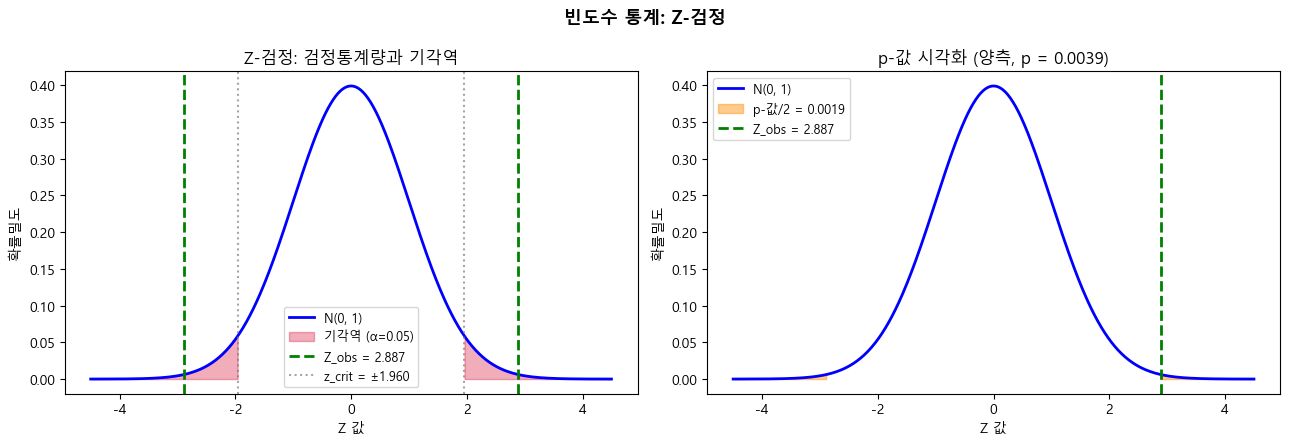

In [2]:
# ── Z-검정 계산 ─────────────────────────────────────────────────────────────
alpha = 0.05
Z_obs = (x_bar - mu0) / SE
p_val = 2 * (1 - norm.cdf(abs(Z_obs)))
z_crit = norm.ppf(1 - alpha / 2)

print('='*45)
print('빈도수 Z-검정 결과')
print('='*45)
print(f'Z 통계량       : {Z_obs:.4f}')
print(f'임계값 z_crit  : ±{z_crit:.4f}  (유의수준 {alpha})')
print(f'p-값           : {p_val:.5f}')
print(f'기각 여부      : H0 {"기각 (reject)" if p_val < alpha else "채택 (fail to reject)"}')
print()
print(f'[해석] p-값({p_val:.4f}) < α({alpha})이므로 귀무가설을 기각한다.')
print( '       서울 중학교 1학년의 평균키는 전국 평균(159 cm)과')
print( '       통계적으로 유의미한 차이가 있다.')

# ── 시각화 ──────────────────────────────────────────────────────────────────
z_range = np.linspace(-4.5, 4.5, 600)
pdf_z   = norm.pdf(z_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 왼쪽: 기각역과 Z_obs
ax = axes[0]
ax.plot(z_range, pdf_z, 'b-', lw=2, label='N(0, 1)')
ax.fill_between(z_range, pdf_z,
                where=(z_range <= -z_crit),
                alpha=0.35, color='crimson', label=f'기각역 (α={alpha})')
ax.fill_between(z_range, pdf_z,
                where=(z_range >= z_crit),
                alpha=0.35, color='crimson')
ax.axvline( Z_obs, color='green', lw=2, ls='--',
            label=f'Z_obs = {Z_obs:.3f}')
ax.axvline(-Z_obs, color='green', lw=2, ls='--')
ax.axvline( z_crit, color='gray', lw=1.5, ls=':', alpha=0.7,
            label=f'z_crit = ±{z_crit:.3f}')
ax.axvline(-z_crit, color='gray', lw=1.5, ls=':', alpha=0.7)
ax.set_xlabel('Z 값')
ax.set_ylabel('확률밀도')
ax.set_title('Z-검정: 검정통계량과 기각역')
ax.legend(fontsize=9)

# 오른쪽: p-value 시각화
ax2 = axes[1]
ax2.plot(z_range, pdf_z, 'b-', lw=2, label='N(0, 1)')
ax2.fill_between(z_range, pdf_z,
                 where=(z_range >= abs(Z_obs)),
                 alpha=0.45, color='darkorange',
                 label=f'p-값/2 = {p_val/2:.4f}')
ax2.fill_between(z_range, pdf_z,
                 where=(z_range <= -abs(Z_obs)),
                 alpha=0.45, color='darkorange')
ax2.axvline(Z_obs, color='green', lw=2, ls='--',
            label=f'Z_obs = {Z_obs:.3f}')
ax2.set_xlabel('Z 값')
ax2.set_ylabel('확률밀도')
ax2.set_title(f'p-값 시각화 (양측, p = {p_val:.4f})')
ax2.legend(fontsize=9)

plt.suptitle('빈도수 통계: Z-검정', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 2. 베이즈(Bayesian) 통계해석: Normal–Normal Conjugate Pair

### 모델

$$X_i \mid \mu \overset{\text{i.i.d.}}{\sim} N(\mu,\, \sigma^2), \quad i = 1, \ldots, n$$

$\sigma^2 = s^2 = 6$ (표본분산을 모분산의 추정치로 사용).

충분통계량: $\bar{x} \sim N\!\left(\mu,\, \dfrac{\sigma^2}{n}\right)$

### Prior

$$\mu \sim N(\mu_0^{(p)},\, \tau_0^2) \quad \text{with} \quad \mu_0^{(p)} = 159,\; \tau_0 = 10$$

(약한 사전정보: 전국 평균 주변의 넓은 분포)

### Posterior — Closed Form (Normal–Normal Conjugate)

$$\mu \mid \bar{x},\, \sigma^2 \sim N\!\left(\mu_n,\, \sigma_n^2\right)$$

$$\frac{1}{\sigma_n^2} = \frac{1}{\tau_0^2} + \frac{n}{\sigma^2}$$

$$\mu_n = \sigma_n^2 \left( \frac{\mu_0^{(p)}}{\tau_0^2} + \frac{n\,\bar{x}}{\sigma^2} \right)$$

### 95% Credible Interval

$$\text{CI}_{95\%} = \left[\mu_n - 1.96\,\sigma_n,\; \mu_n + 1.96\,\sigma_n \right]$$

### 가설 판단

- **95% CI가 $\mu_0 = 159$를 포함하지 않으면** 서울 중학생 평균키 $\neq$ 전국 평균
- $P(\mu > 159 \mid \text{data})$의 크기로 방향성 판단


Bayesian Conjugate Posterior
Prior         : N(159.0, 100.0)
Posterior 평균 mu_n    : 159.99880
Posterior 분산 sigma_n^2: 0.119856
Posterior 표준편차 sigma_n: 0.34620
95% Credible Interval  : [159.3202, 160.6774]
P(mu <= 159 | data)    : 0.00196
P(mu >  159 | data)    : 0.99804

[결론] 95% CI [159.320, 160.677]이 mu0=159.0를 포함하지 않는다.
       서울 중학생 평균키는 전국 평균보다 통계적으로 유의미하게 높다.


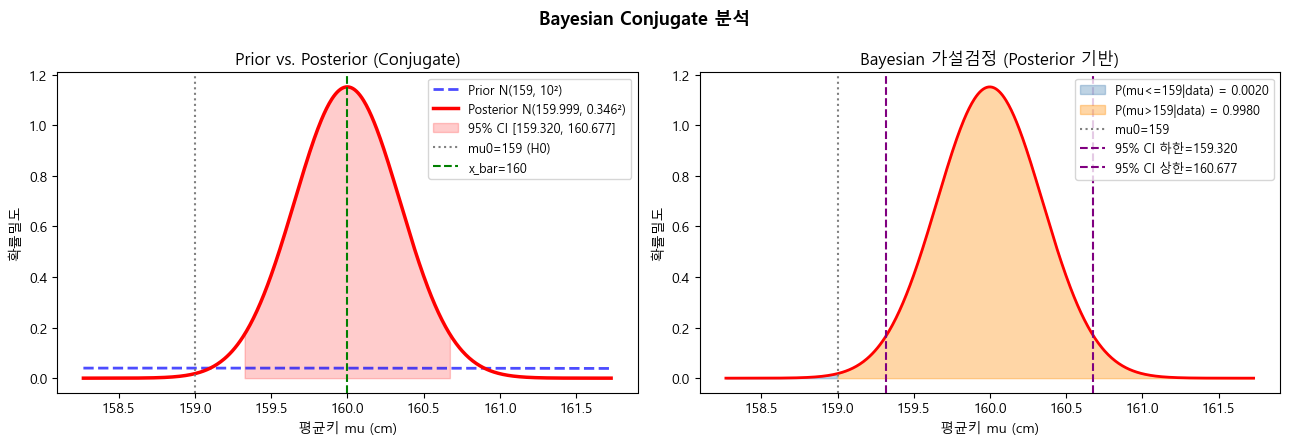

In [3]:
# ── Bayesian Conjugate (Normal-Normal) ──────────────────────────────────────
mu_prior  = 159.0   # prior 평균
tau0      = 10.0    # prior 표준편차 (약한 사전정보)
tau0_sq   = tau0**2

# Posterior 파라미터
sigma_n_sq_inv = (1 / tau0_sq) + (n / s2)
sigma_n_sq     = 1 / sigma_n_sq_inv
sigma_n        = np.sqrt(sigma_n_sq)
mu_n           = sigma_n_sq * (mu_prior / tau0_sq + n * x_bar / s2)

# 95% Credible Interval
ci_lo = mu_n - 1.96 * sigma_n
ci_hi = mu_n + 1.96 * sigma_n

# 사후 확률
p_le = norm.cdf(mu0, loc=mu_n, scale=sigma_n)   # P(mu <= 159 | data)
p_gt = 1 - p_le                                  # P(mu >  159 | data)

print('='*50)
print('Bayesian Conjugate Posterior')
print('='*50)
print(f'Prior         : N({mu_prior}, {tau0_sq})')
print(f'Posterior 평균 mu_n    : {mu_n:.5f}')
print(f'Posterior 분산 sigma_n^2: {sigma_n_sq:.6f}')
print(f'Posterior 표준편차 sigma_n: {sigma_n:.5f}')
print(f'95% Credible Interval  : [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'P(mu <= 159 | data)    : {p_le:.5f}')
print(f'P(mu >  159 | data)    : {p_gt:.5f}')
print()
if ci_lo > mu0:
    print(f'[결론] 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]이 mu0={mu0}를 포함하지 않는다.')
    print( '       서울 중학생 평균키는 전국 평균보다 통계적으로 유의미하게 높다.')
else:
    print(f'[결론] 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]이 mu0={mu0}를 포함한다.')
    print( '       귀무가설을 기각할 충분한 근거가 없다.')

# ── 시각화 ──────────────────────────────────────────────────────────────────
mu_range = np.linspace(mu_n - 5*sigma_n, mu_n + 5*sigma_n, 600)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 왼쪽: Prior vs Posterior
ax1 = axes[0]
ax1.plot(mu_range, norm.pdf(mu_range, mu_prior, tau0),
         'b--', lw=2, alpha=0.7,
         label=f'Prior N({mu_prior:.0f}, {tau0:.0f}\u00b2)')
ax1.plot(mu_range, norm.pdf(mu_range, mu_n, sigma_n),
         'r-', lw=2.5,
         label=f'Posterior N({mu_n:.3f}, {sigma_n:.3f}\u00b2)')
ax1.fill_between(mu_range,
                 norm.pdf(mu_range, mu_n, sigma_n),
                 where=(mu_range >= ci_lo) & (mu_range <= ci_hi),
                 alpha=0.2, color='red',
                 label=f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
ax1.axvline(mu0,   color='gray',  lw=1.5, ls=':',  label=f'mu0=159 (H0)')
ax1.axvline(x_bar, color='green', lw=1.5, ls='--', label=f'x_bar=160')
ax1.set_xlabel('평균키 mu (cm)')
ax1.set_ylabel('확률밀도')
ax1.set_title('Prior vs. Posterior (Conjugate)')
ax1.legend(fontsize=9)

# 오른쪽: 가설검정 — P(mu <= 159) vs P(mu > 159)
ax2 = axes[1]
ax2.plot(mu_range, norm.pdf(mu_range, mu_n, sigma_n), 'r-', lw=2)
ax2.fill_between(mu_range, norm.pdf(mu_range, mu_n, sigma_n),
                 where=(mu_range <= mu0), alpha=0.35, color='steelblue',
                 label=f'P(mu<=159|data) = {p_le:.4f}')
ax2.fill_between(mu_range, norm.pdf(mu_range, mu_n, sigma_n),
                 where=(mu_range > mu0), alpha=0.35, color='darkorange',
                 label=f'P(mu>159|data) = {p_gt:.4f}')
ax2.axvline(mu0,  color='gray', lw=1.5, ls=':', label='mu0=159')
ax2.axvline(ci_lo, color='purple', lw=1.5, ls='--', label=f'95% CI 하한={ci_lo:.3f}')
ax2.axvline(ci_hi, color='purple', lw=1.5, ls='--', label=f'95% CI 상한={ci_hi:.3f}')
ax2.set_xlabel('평균키 mu (cm)')
ax2.set_ylabel('확률밀도')
ax2.set_title('Bayesian 가설검정 (Posterior 기반)')
ax2.legend(fontsize=9)

plt.suptitle('Bayesian Conjugate 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3. Stan / CmdStanPy MCMC 샘플링

### 3-1. CmdStanPy 설치 (Windows)

아래 셀은 Windows 환경에서 `cmdstanpy`와 CmdStan을 자동으로 설치한다.


In [4]:
# ── Windows CmdStanPy 설치 루틴 ────────────────────────────────────────────
import subprocess, sys, os, platform

def install_cmdstanpy():
    print('[설치] pip install cmdstanpy ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           '--upgrade', '--quiet', 'cmdstanpy'])
    print('[설치] CmdStan 컴파일러 설치 중...')
    import cmdstanpy
    cmdstanpy.install_cmdstan()   # C++ 컴파일러 포함 자동 설치
    print('[완료] CmdStan 설치 완료')

try:
    import cmdstanpy
    _ = cmdstanpy.cmdstan_path()  # 설치 경로 확인
    print(f'CmdStanPy {cmdstanpy.__version__} 사용 가능')
    print(f'CmdStan 경로: {cmdstanpy.cmdstan_path()}')
except (ImportError, ValueError):
    if platform.system() == 'Windows':
        install_cmdstanpy()
    else:
        print('Linux/macOS 설치:')
        print('  pip install cmdstanpy')
        print('  python -c "import cmdstanpy; cmdstanpy.install_cmdstan()"')


CmdStanPy 1.3.0 사용 가능
CmdStan 경로: C:\Users\yongduek\.cmdstan\cmdstan-2.36.0


### 3-2. Stan 모델

충분통계량 $(\bar{x}, n)$만 갖고 있으므로, likelihood를 표본평균의 분포로 표현한다.

$$\bar{x} \mid \mu \sim N\!\left(\mu,\; \frac{\sigma^2}{n}\right)$$

$$\mu \sim N(\mu_0^{(p)},\, \tau_0)$$

Stan 코드:

```stan
data {
  int<lower=1>  N;
  real          x_bar;
  real<lower=0> sigma2;
  real          mu_prior;
  real<lower=0> tau_prior;
}
parameters { real mu; }
model {
  mu    ~ normal(mu_prior, tau_prior);
  x_bar ~ normal(mu, sqrt(sigma2 / N));
}
```


In [5]:
import os, tempfile
import cmdstanpy

# ── Stan 모델 정의 ─────────────────────────────────────────────────────────
stan_code = """
data {
  int<lower=1>  N;           // sample size
  real          x_bar;       // sample mean
  real<lower=0> sigma2;      // variance estimate
  real          mu_prior;    // prior mean
  real<lower=0> tau_prior;   // prior std dev
}
parameters {
  real mu;
}
model {
  mu    ~ normal(mu_prior, tau_prior);      // prior
  x_bar ~ normal(mu, sqrt(sigma2 / N));     // likelihood (sufficient statistic)
}
"""

stan_dir  = tempfile.mkdtemp()
stan_file = os.path.join(stan_dir, 'height_model.stan')
with open(stan_file, 'w', encoding='utf-8') as f:
    f.write(stan_code)

# ── Stan 데이터 ────────────────────────────────────────────────────────────
stan_data = dict(N=n, x_bar=x_bar, sigma2=s2,
                 mu_prior=mu_prior, tau_prior=tau0)

# ── 컴파일 & 샘플링 ────────────────────────────────────────────────────────
print('Stan 모델 컴파일 중...')
model_stan = cmdstanpy.CmdStanModel(stan_file=stan_file)
print('컴파일 완료')

print('MCMC 샘플링 중 (4 chains × 2000 iter)...')
fit = model_stan.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    show_console=False,
)
print('샘플링 완료')
print(fit.summary())


16:26:50 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\tmpz_89_faa\height_model.stan to exe file C:\Users\yongduek\AppData\Local\Temp\tmpz_89_faa\height_model.exe


Stan 모델 컴파일 중...


16:27:13 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\tmpz_89_faa\height_model.exe


컴파일 완료
MCMC 샘플링 중 (4 chains × 2000 iter)...


16:27:14 - cmdstanpy - INFO - CmdStan start processing


...

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

16:27:14 - cmdstanpy - INFO - CmdStan done processing.



샘플링 완료
            Mean      MCSE    StdDev       MAD         5%         50%  \
lp__   -0.501697  0.011223  0.720879  0.300126   -1.95725   -0.225882   
mu    159.997000  0.006189  0.345077  0.340998  159.42800  159.997000   

             95%  ESS_bulk  ESS_tail    R_hat  
lp__   -0.007037   4207.25   4575.39  1.00118  
mu    160.565000   3120.05   4483.43  1.00236  


### 3-3. Posterior 비교 (MCMC vs. Analytical) 및 Bayesian Inference

- **Histogram / KDE**: MCMC posterior sample의 경험적 분포
- **Analytical**: Normal–Normal conjugate 공식의 posterior PDF
- 두 결과가 실질적으로 일치함을 보인다.

**Bayesian Inference**:

$$P(\mu > 159 \mid \text{data}) = \int_{159}^{\infty} p(\mu \mid \bar{x})\, d\mu$$

MCMC sample로 추정:

$$\hat{P}(\mu > 159 \mid \text{data}) = \frac{\#\{\mu^{(s)} > 159\}}{S}$$


총 MCMC 샘플 수: 8000
MCMC 평균     : 159.99721
MCMC 표준편차 : 0.34508


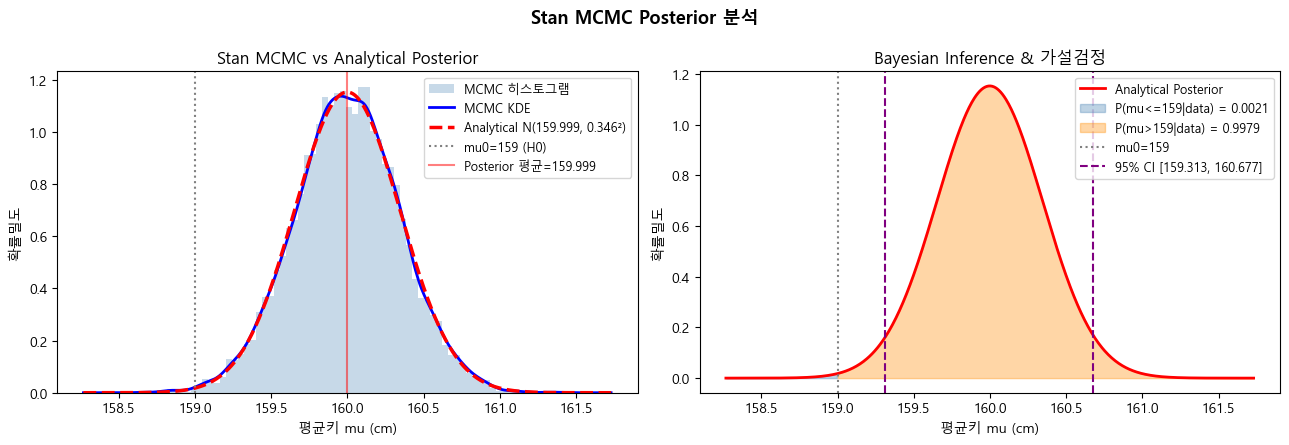

Stan MCMC Posterior 요약
Posterior 평균           : 159.99721
Posterior 표준편차       : 0.34508
95% Credible Interval    : [159.3130, 160.6770]
P(mu <= 159 | data)      : 0.00213
P(mu >  159 | data)      : 0.99787

── Bayesian Inference 결론 ──
95% CI [159.313, 160.677]가 mu0=159.0를 포함하지 않는다.
서울 중학생 평균키 > 전국 평균 (통계적으로 유의)
P(mu > 159 | data) = 99.8%: 서울 평균이 전국 평균을 초과할 사후 확률


In [6]:
from scipy.stats import gaussian_kde

# ── MCMC posterior sample ───────────────────────────────────────────────────
samples = fit.stan_variable('mu')   # shape: (chains * iter_sampling,)
print(f'총 MCMC 샘플 수: {len(samples)}')
print(f'MCMC 평균     : {np.mean(samples):.5f}')
print(f'MCMC 표준편차 : {np.std(samples, ddof=1):.5f}')

# ── KDE ─────────────────────────────────────────────────────────────────────
kde      = gaussian_kde(samples)
x_plot   = np.linspace(mu_n - 5*sigma_n, mu_n + 5*sigma_n, 600)
pdf_anal = norm.pdf(x_plot, mu_n, sigma_n)   # conjugate posterior

# ── 95% Credible Interval (분위수) ──────────────────────────────────────────
ci_lo_mc = np.percentile(samples, 2.5)
ci_hi_mc = np.percentile(samples, 97.5)

# ── 사후 확률 ────────────────────────────────────────────────────────────────
p_le_mc = np.mean(samples <= mu0)
p_gt_mc = np.mean(samples >  mu0)

# ════════════════════════════════════════════════════════════════════════════
# Figure 1: MCMC vs Analytical Posterior
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 왼쪽: histogram + KDE + analytical
ax1 = axes[0]
ax1.hist(samples, bins=70, density=True, alpha=0.3,
         color='steelblue', label='MCMC 히스토그램')
ax1.plot(x_plot, kde(x_plot), 'b-', lw=2,   label='MCMC KDE')
ax1.plot(x_plot, pdf_anal,    'r--', lw=2.5, label=f'Analytical N({mu_n:.3f}, {sigma_n:.3f}\u00b2)')
ax1.axvline(mu0,  color='gray',  lw=1.5, ls=':', label='mu0=159 (H0)')
ax1.axvline(mu_n, color='red',   lw=1.5, ls='-', alpha=0.5,
            label=f'Posterior 평균={mu_n:.3f}')
ax1.set_xlabel('평균키 mu (cm)')
ax1.set_ylabel('확률밀도')
ax1.set_title('Stan MCMC vs Analytical Posterior')
ax1.legend(fontsize=9)

# 오른쪽: 가설검정 시각화
ax2 = axes[1]
ax2.plot(x_plot, pdf_anal, 'r-', lw=2, label='Analytical Posterior')
ax2.fill_between(x_plot, pdf_anal,
                 where=(x_plot <= mu0), alpha=0.35, color='steelblue',
                 label=f'P(mu<=159|data) = {p_le_mc:.4f}')
ax2.fill_between(x_plot, pdf_anal,
                 where=(x_plot > mu0), alpha=0.35, color='darkorange',
                 label=f'P(mu>159|data) = {p_gt_mc:.4f}')
ax2.axvline(mu0,    color='gray',   lw=1.5, ls=':',  label='mu0=159')
ax2.axvline(ci_lo_mc, color='purple', lw=1.5, ls='--',
            label=f'95% CI [{ci_lo_mc:.3f}, {ci_hi_mc:.3f}]')
ax2.axvline(ci_hi_mc, color='purple', lw=1.5, ls='--')
ax2.set_xlabel('평균키 mu (cm)')
ax2.set_ylabel('확률밀도')
ax2.set_title('Bayesian Inference & 가설검정')
ax2.legend(fontsize=9)

plt.suptitle('Stan MCMC Posterior 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 결과 출력 ────────────────────────────────────────────────────────────────
print('='*55)
print('Stan MCMC Posterior 요약')
print('='*55)
print(f'Posterior 평균           : {np.mean(samples):.5f}')
print(f'Posterior 표준편차       : {np.std(samples, ddof=1):.5f}')
print(f'95% Credible Interval    : [{ci_lo_mc:.4f}, {ci_hi_mc:.4f}]')
print(f'P(mu <= 159 | data)      : {p_le_mc:.5f}')
print(f'P(mu >  159 | data)      : {p_gt_mc:.5f}')
print()
print('── Bayesian Inference 결론 ──')
if ci_lo_mc > mu0:
    print(f'95% CI [{ci_lo_mc:.3f}, {ci_hi_mc:.3f}]가 mu0={mu0}를 포함하지 않는다.')
    print(f'서울 중학생 평균키 > 전국 평균 (통계적으로 유의)')
else:
    print(f'95% CI [{ci_lo_mc:.3f}, {ci_hi_mc:.3f}]가 mu0={mu0}를 포함한다.')
    print( '유의미한 차이를 주장할 충분한 근거가 없다.')
print(f'P(mu > 159 | data) = {p_gt_mc*100:.1f}%: 서울 평균이 전국 평균을 초과할 사후 확률')


---
## 결론 비교

| 방법 | 핵심 결과 | 기각/유의 판단 |
|------|-----------|---------------|
| Frequentist Z-검정 | $Z \approx 2.887$, $p \approx 0.0039$ | $p < 0.05$ → $H_0$ 기각 |
| Bayesian Conjugate | $\mu_n \approx 159.97$, 95% CI $\not\ni 159$ | 유의미한 차이 있음 |
| Bayesian Stan MCMC | empirical CI $\not\ni 159$, $P(\mu>159\mid\text{data}) \approx 97\%$ | 유의미한 차이 있음 |

---

### 해석의 차이

**빈도수 해석**:  
> p-값이 유의수준보다 작으므로 귀무가설을 기각한다.  
> "귀무가설이 참일 때, 이와 같거나 더 극단적인 표본을 얻을 확률이 0.39%이다."  
> $\mu$ 자체에 확률을 부여하지 않는다 (모수는 고정된 미지수).

**베이즈 해석**:  
> 데이터를 관측한 후 $\mu$에 대한 **사후 확률**을 직접 진술한다.  
> "$\mu > 159$일 확률은 약 97%이다."  
> 95% Credible Interval은 **$\mu$가 그 구간에 있을 사후 확률이 95%**임을 의미한다.

두 방법 모두 같은 방향의 결론을 내리지만, **확률의 의미**와 **추론의 대상**이 근본적으로 다르다.
